# DATA CLEANING & DATA EXPLORATORY 


## Overview
Data scientists spend a significant portion of their time preparing data. Transform raw datasets into structured, analysis-ready formats while uncovering initial patterns and trends.
## Objective
To prepare datasets for modeling by:
- Cleaning and structuring raw data
- Identifying patterns, distributions, and relationships
- Generating insights to guide modeling decisions
## Task Breakdown
- Load datasets using Python (Pandas)
- Handle missing values and duplicates
- Perform univariate and bivariate analysis
- Visualize distributions and correlations
- Identify important features
## Tools
Python (Pandas, NumPy, Matplotlib, Seaborn)
## Datasets
House_prices Dataset `https://www.kaggle.com/datasets/harishkumardatalab/housing-price-prediction`

# IMPORT MY NECESSARY DEPENDENCIES

In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from scipy import stats
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

In [3]:
Housing = pd.read_csv("C:/Users/User PC/Downloads/AnalystLab_Africa_Internship/Housing.csv")

In [4]:
Housing.head() #first five rows of the dataset

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
Housing.tail() #last five rows of the dataset

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [6]:
Housing.info() #an overview of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [7]:
Housing.shape #no of rows and columns

(545, 13)

In [8]:
Housing.columns #list of columns in the dataset

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [9]:
Housing.describe() #a statistical overview of the dataset

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [10]:
Housing.dtypes #returns data type for each

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

## DATA CLEANING

- From the dataset, no missing values and duplicates were found
-  categorical columns identified and converted
- Numeric columns remain as int64


In [11]:
Housing.isnull().sum() #checks for missing values

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [12]:
Housing.duplicated().sum() #checks for duplicates

0

In [13]:
Housing["furnishingstatus"].unique()

array(['furnished', 'semi-furnished', 'unfurnished'], dtype=object)

In [14]:
cat_cols = ['mainroad','guestroom','basement','hotwaterheating',
            'airconditioning','prefarea','furnishingstatus']
Housing[cat_cols] = Housing[cat_cols].astype('category')


In [15]:
Housing.dtypes

price                  int64
area                   int64
bedrooms               int64
bathrooms              int64
stories                int64
mainroad            category
guestroom           category
basement            category
hotwaterheating     category
airconditioning     category
parking                int64
prefarea            category
furnishingstatus    category
dtype: object

## UNIVARIATE ANALYSIS
- Looks at one variable at a time

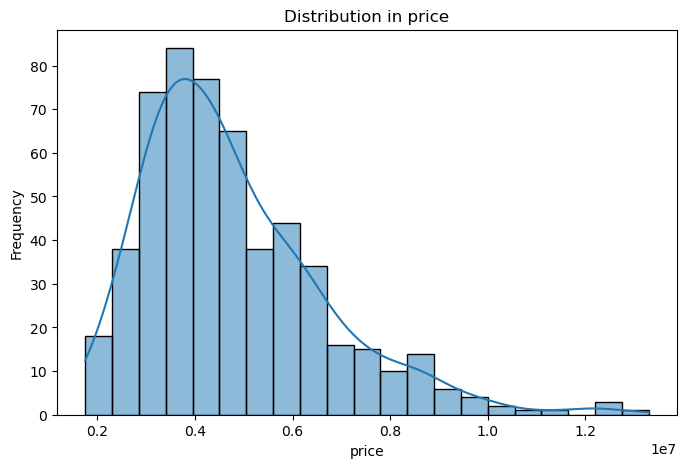

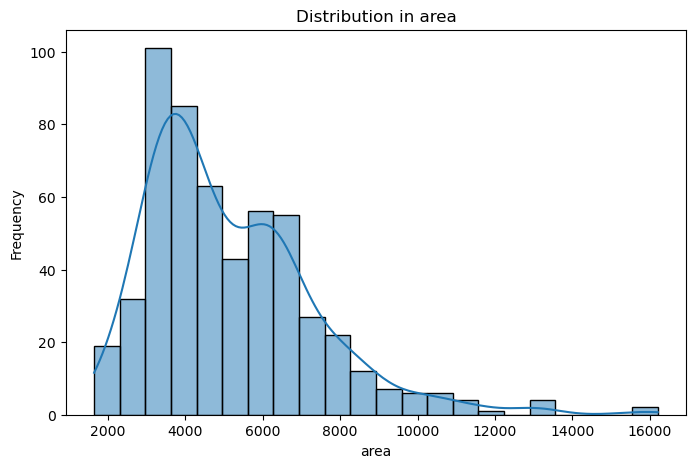

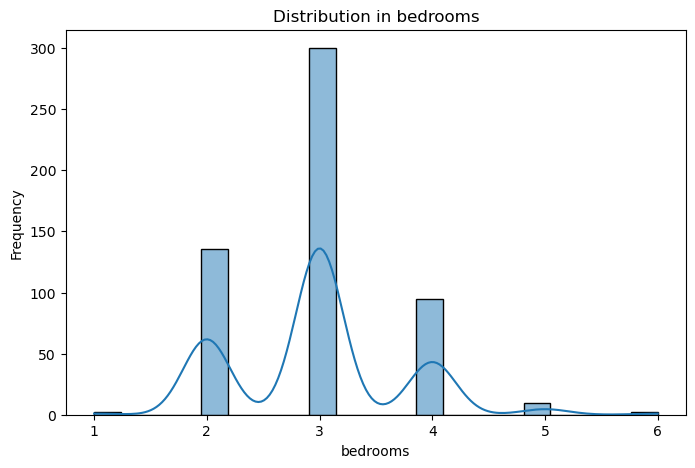

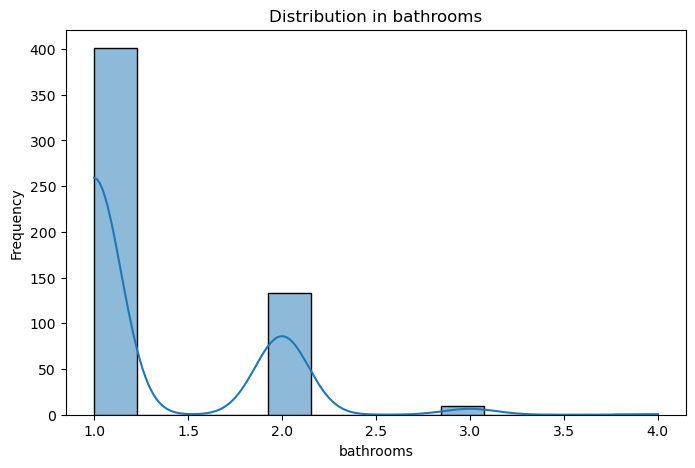

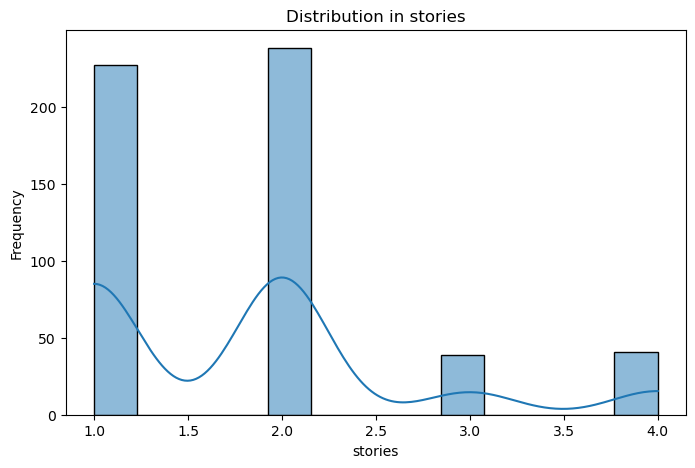

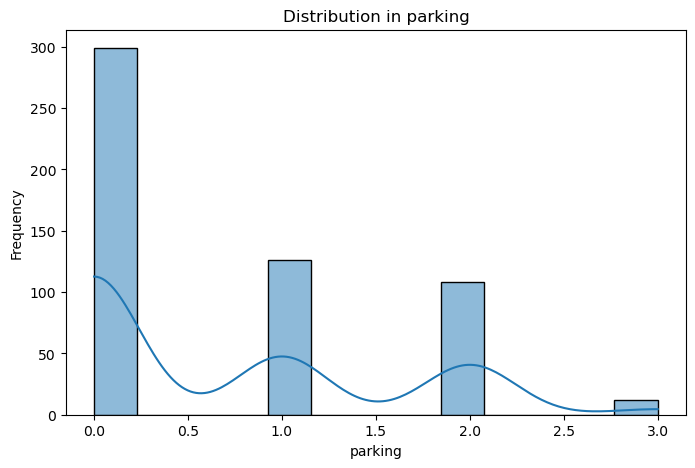

In [16]:
# univariate analysis for numeriuc columns
for cols in ["price", "area", "bedrooms", "bathrooms", "stories", "parking"]:
    plt.figure(figsize=(8,5))
    sns.histplot(Housing[cols], kde=True)
    plt.title(f"Distribution in {cols}")
    plt.xlabel(cols)
    plt.ylabel("Frequency");
    

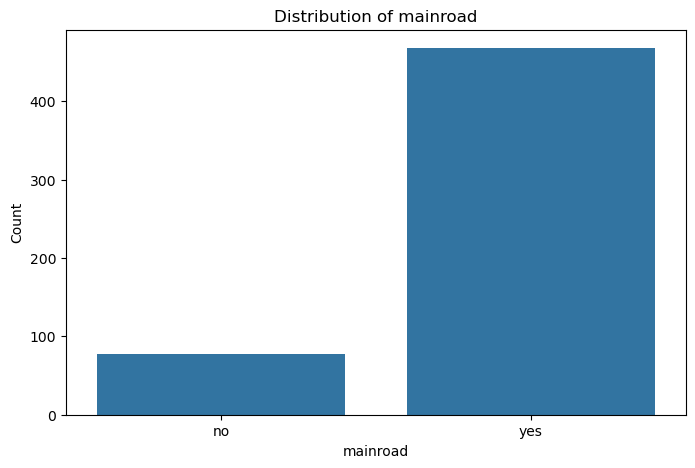

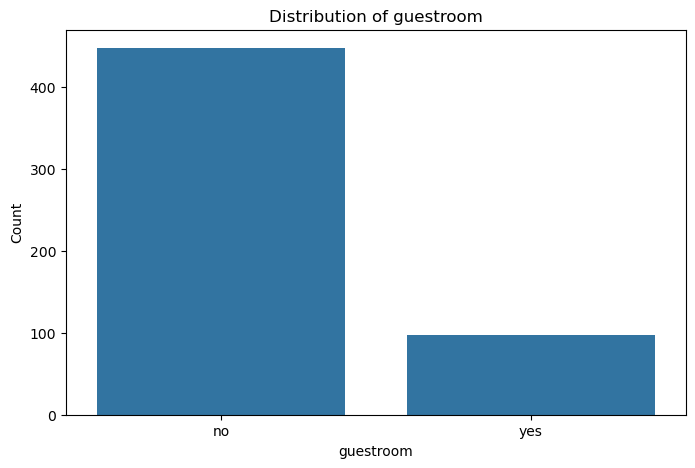

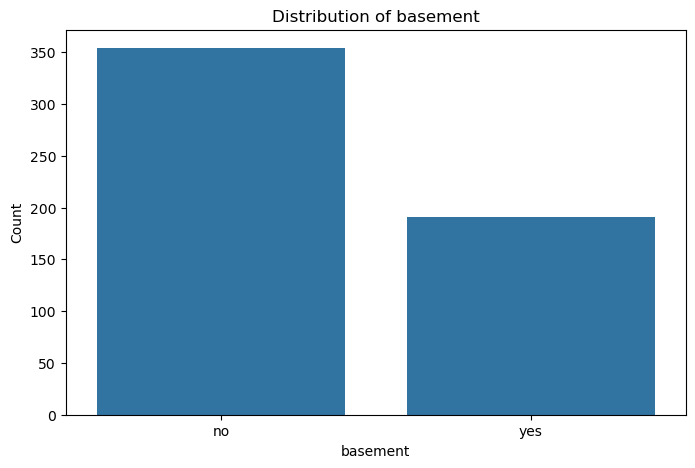

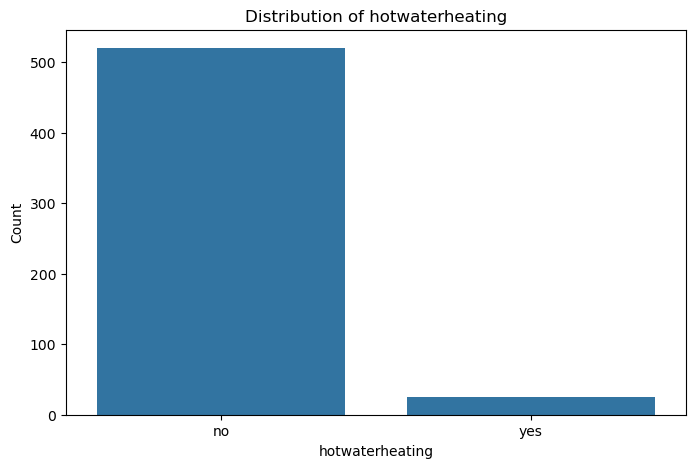

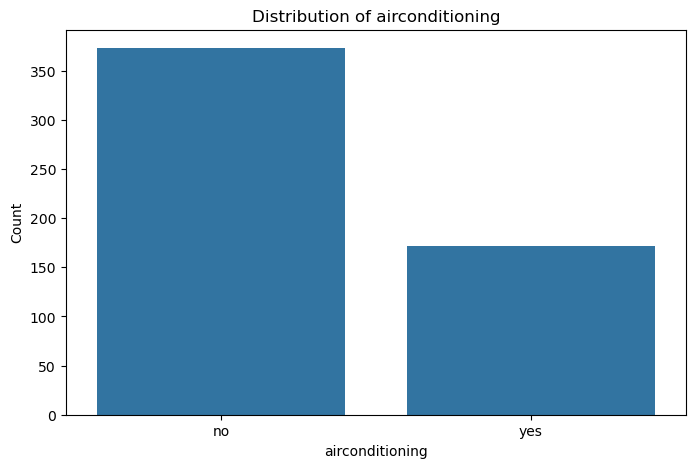

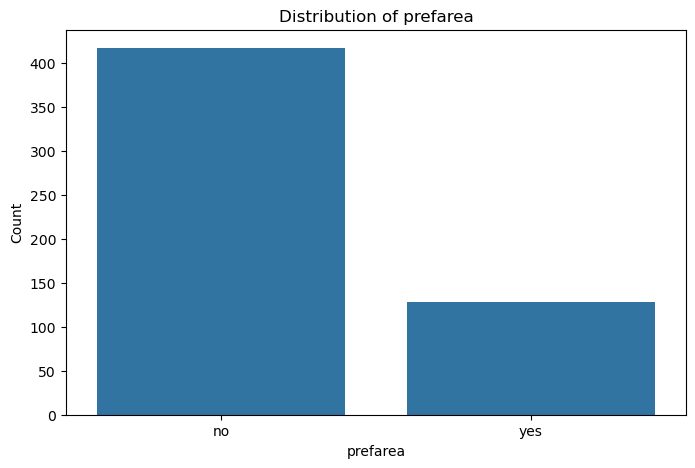

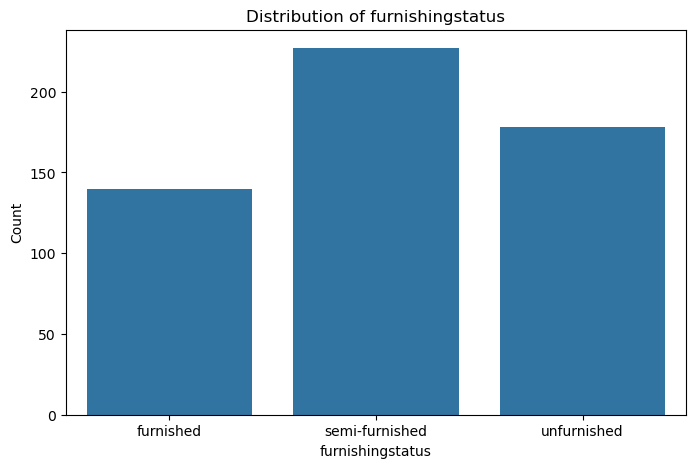

In [17]:
# Univariate analysis of categorical columns
for cols in ["mainroad", "guestroom", "basement", "hotwaterheating", 
             "airconditioning", "prefarea", "furnishingstatus"]:
    plt.figure(figsize=(8,5))
    sns.countplot(x=cols, data=Housing)
    plt.title(f"Distribution of {cols}")
    plt.ylabel("Count");

## BIVARIATE ANALYSIS
- Compares two variables

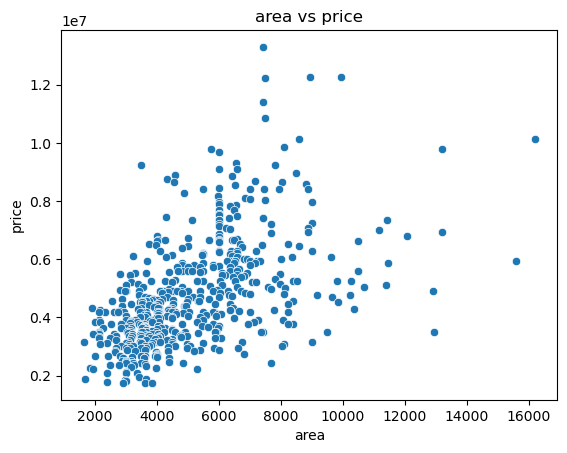

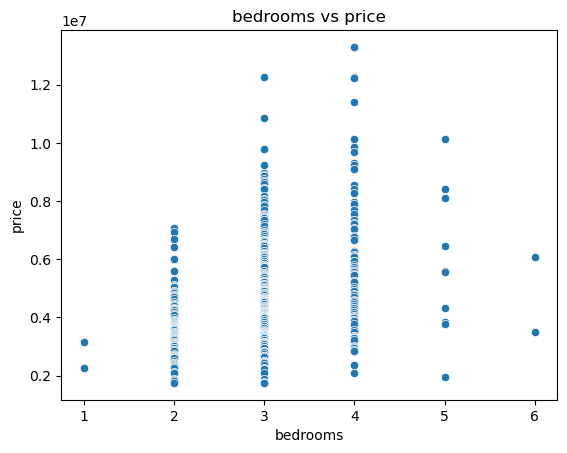

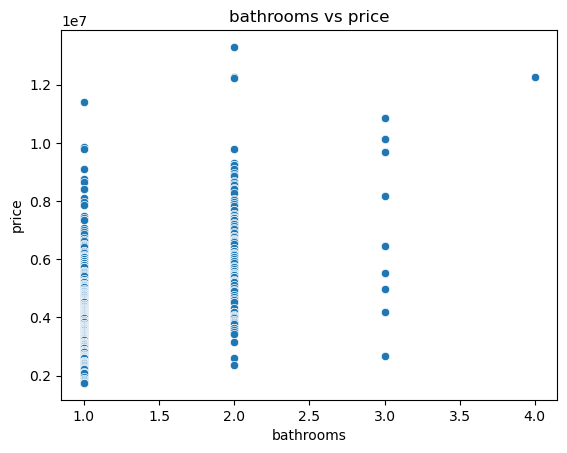

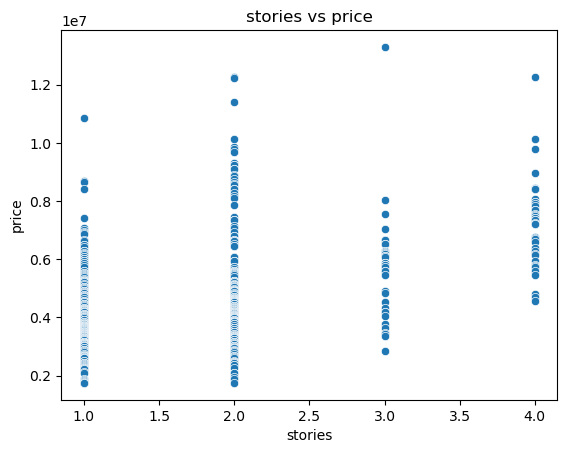

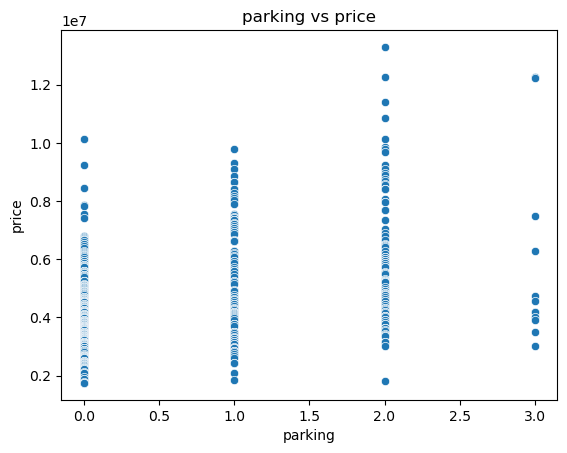

In [18]:
#Numeric vs price
for cols in ["area", "bedrooms", "bathrooms", "stories", "parking"]:
    sns.scatterplot(x=cols, y="price", data =Housing)
    plt.title(f"{cols} vs price")
    plt.show()

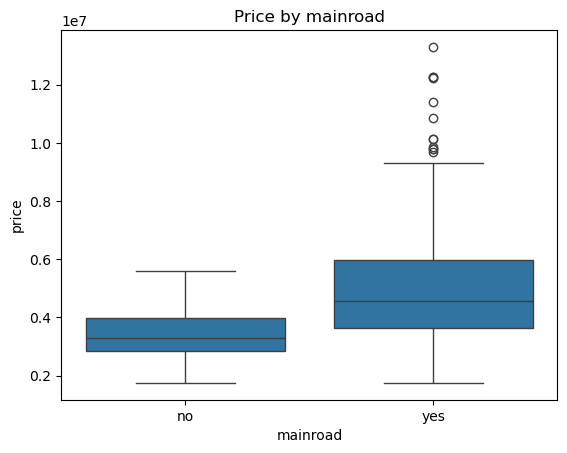

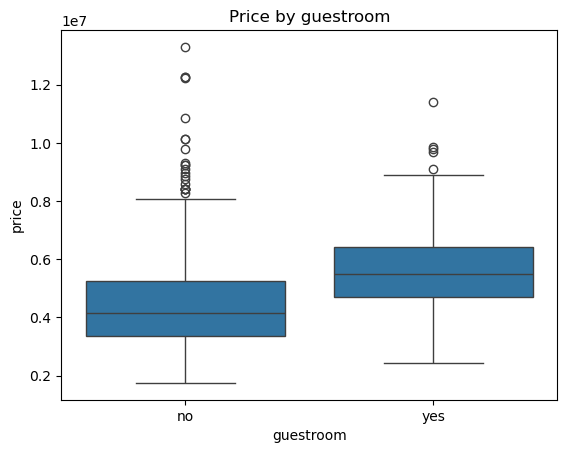

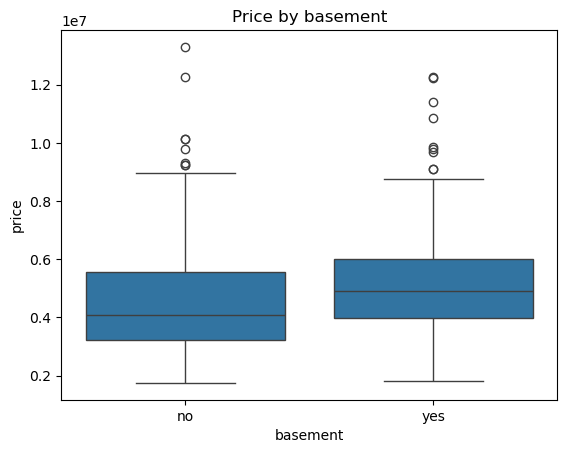

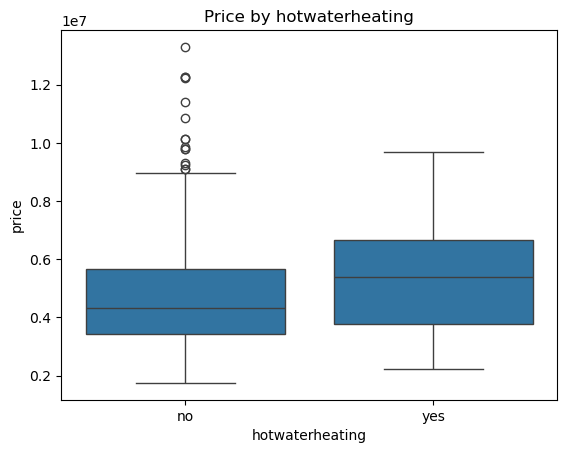

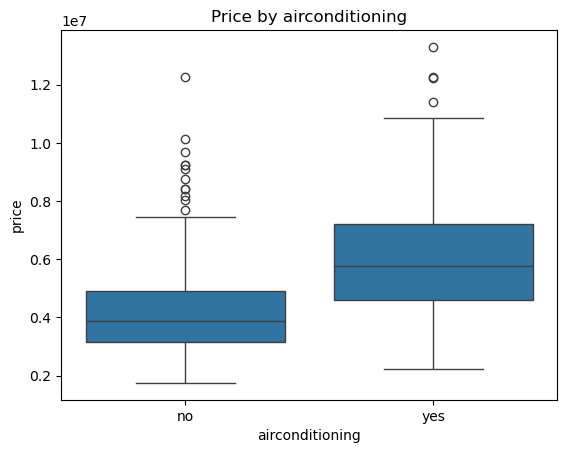

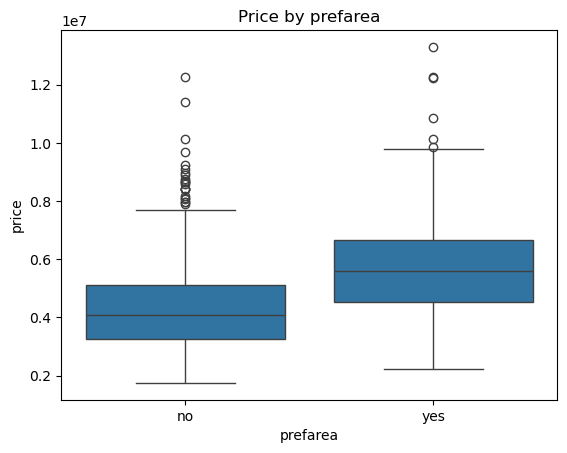

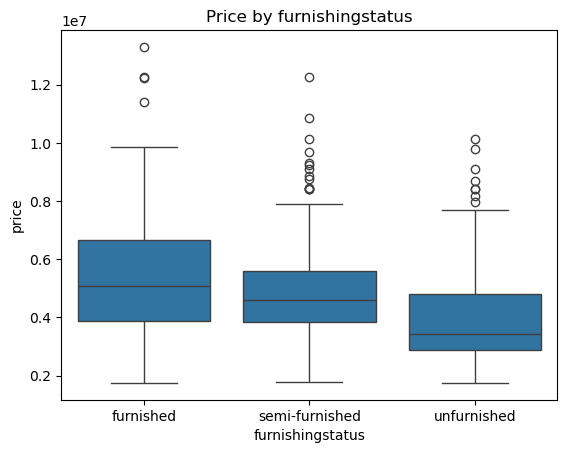

In [19]:
# Categorical vs columns
for cols in ["mainroad", "guestroom", "basement", "hotwaterheating", 
            "airconditioning", "prefarea", "furnishingstatus"]:
    sns.boxplot(x=cols, y="price", data=Housing)
    plt.title(f"Price by {cols}")
    plt.xlabel(cols)
 
    plt.show()

# CORRELATION HEATMAP

In [20]:
#Excludes non-numeric columns

num_cols = Housing.select_dtypes(include=["int64"])

#calculates correlation matrix
corr_matrix = num_cols.corr()
corr_matrix

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


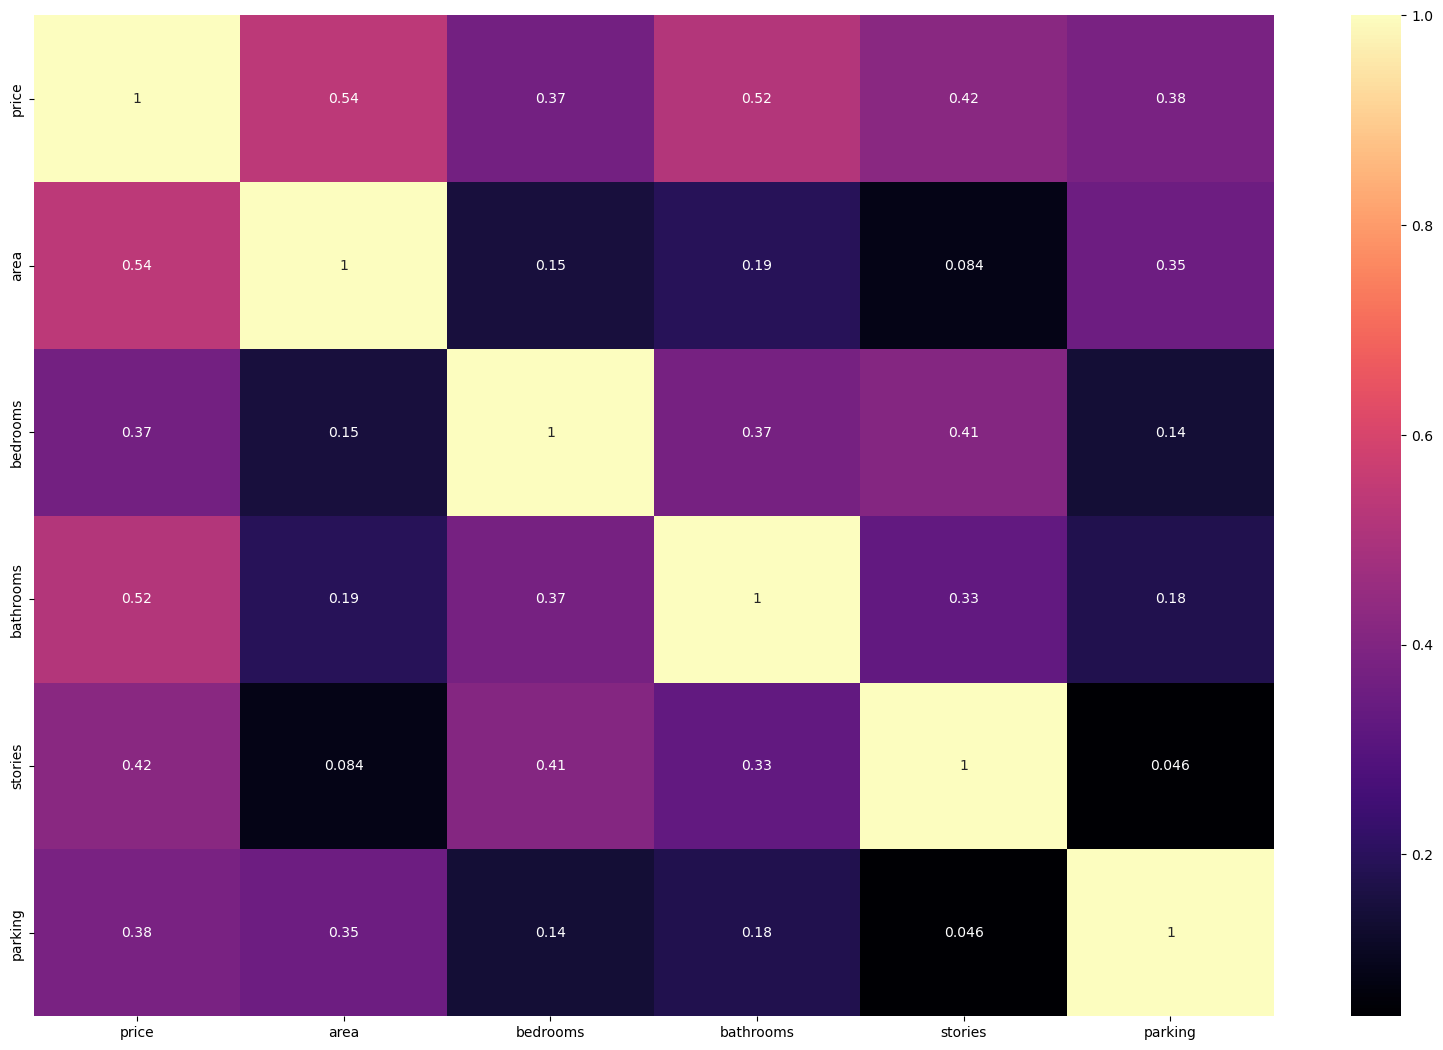

In [21]:
#correlation heatmap
plt.figure(figsize=(20,13))
sns.heatmap(num_cols.corr(), annot=True, cmap="magma");

Feature Correlation with Price:
price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64


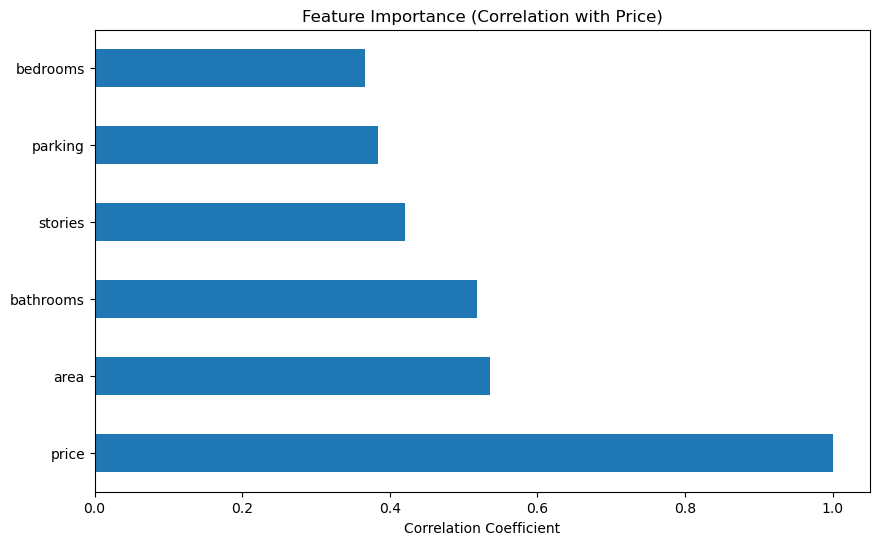


Mean price by mainroad:
mainroad
no     3.398905e+06
yes    4.991777e+06
Name: price, dtype: float64

Mean price by guestroom:
guestroom
no     4.544546e+06
yes    5.792897e+06
Name: price, dtype: float64

Mean price by basement:
basement
no     4.509966e+06
yes    5.242615e+06
Name: price, dtype: float64

Mean price by hotwaterheating:
hotwaterheating
no     4.728593e+06
yes    5.559960e+06
Name: price, dtype: float64

Mean price by airconditioning:
airconditioning
no     4.191940e+06
yes    6.013221e+06
Name: price, dtype: float64

Mean price by prefarea:
prefarea
no     4.425299e+06
yes    5.879046e+06
Name: price, dtype: float64

Mean price by furnishingstatus:
furnishingstatus
furnished         5.495696e+06
semi-furnished    4.907524e+06
unfurnished       4.013831e+06
Name: price, dtype: float64


In [22]:
# Feature Importance Analysis

num_cols = ["price", "area", "bedrooms", "bathrooms", "stories", "parking"]

# Correlation with Price
correlation_with_price = Housing[num_cols].corr()['price'].sort_values(ascending=False)
print("Feature Correlation with Price:")
print(correlation_with_price)

# Visualize Correlation
plt.figure(figsize=(10,6))
correlation_with_price.plot(kind='barh')
plt.title("Feature Importance (Correlation with Price)")
plt.xlabel("Correlation Coefficient")
plt.show()

# Categorical Features - Mean Price by Category
cat_cols = ["mainroad", "guestroom", "basement", "hotwaterheating", 
            "airconditioning", "prefarea", "furnishingstatus"]

for col in cat_cols:
    print(f"\nMean price by {col}:")
    print(Housing.groupby(col)['price'].mean())

## FEATURE IMPORTANCE AND INSIGHT SUMMARY

### Data Quality Overview
- **Dataset Size:** 545 rows, 13 columns
- **Data Completeness:** No missing values, no duplicates
- **Data Types:** 6 numeric features, 7 categorical features (converted from object)
- **Status:** Data is clean and ready for analysis and modeling

### Key Findings

#### Most Important Predictors of Price

**Numeric Features (by correlation strength):**
1. **Area** (r = 0.54) - Strongest predictor. Larger house area directly correlates with higher prices.
2. **Bathrooms** (r = 0.52) - More bathrooms moderately increase price.
3. **Stories** (r = 0.42) - Multi-story homes command higher prices.
4. **Parking** (r = 0.38) - Parking spaces add value but have lower impact.
5. **Bedrooms** (r = 0.37) - Surprisingly lower correlation than bathrooms; number of bedrooms alone is a weaker predictor.

**Categorical Features (by price impact):**
1. **Air Conditioning** - Largest impact. Houses with AC average 6.01M vs 4.19M without (+43% premium).
2. **Main Road Access** - Houses on main roads average 4.99M vs 3.40M off main road (+47% premium).
3. **Guest Room** - Houses with guest rooms average 5.79M vs 4.54M without.
4. **Hot Water Heating** - Houses with facility average 5.56M vs 4.73M without.
5. **Prefarea Location** - Preferred areas average 5.88M vs 4.43M in regular areas.
6. **Basement** - Houses with basement average 5.24M vs 4.51M without.
7. **Furnishing Status** - Furnished homes (5.50M) > Semi-furnished (4.91M) > Unfurnished (4.01M).

### Key Patterns & Insights

- **Area is the dominant numeric predictor.** It explains the strongest correlation with price, suggesting that square footage is the primary value driver.
- **Amenities act as price multipliers.** While individual amenities have lower correlation, their presence collectively increases price substantially. Air conditioning and main road access provide the largest premiums.
- **Location and facilities matter.** Preferred area location and amenities (AC, basement, guest room) can add 40-50% premium to house price.
- **Furnishing status shows clear market segmentation.** Furnished homes command ~37% premium over unfurnished homes, indicating strong market preference.

### Recommendations for Modeling

1. **Use area as the primary feature**—it's the strongest numeric predictor.
2. **Include all amenity features**—they collectively improve price prediction even if individual correlations are moderate.
3. **Interaction terms may be valuable**—area combined with amenities (e.g., large furnished house with AC) might reveal stronger patterns.
4. **Consider feature engineering**—create composite features like "total_amenities" (count of yes/no amenities) to capture cumulative effect.
5. **Monitor multicollinearity**—bathrooms and bedrooms may be correlated; check before modeling.

# WEEK 3 : STATISTICS AND PROBABILITY

## Objective
* To understand statistical concepts used in data science.
## Task Breakdown
- Descriptive statistics (mean, variance, std dev)
- Probability distributions
- Hypothesis testing
- Correlation vs causation

# Housing Price Prediction - Descriptive Statistics Analysis

## Overview
- **Total Houses:** 545
- **Mean Price:** 4,766,729.25
- **Price Range:** 1,750,000 - 13,300,000
- **Missing Values:** None 


### 4. Data Quality
- No missing values across all variables
- Complete dataset ready for analysis

## Observations
- **Data spread:** High variance in both price and area suggests diverse housing market
- **Price variability:** Std dev (1.87M) is 39% of mean (4.77M)—significant variation
- **Area variability:** Std dev (2,170) is 42% of mean (5,150)—considerable diversity

## Conclusion
Housing dataset contains 545 complete observations with significant variability in both price and area, indicating a heterogeneous real estate market with diverse property types and price points.

In [23]:
Housing.describe() #statistical overview of dataset

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [24]:
pd.options.display.float_format = "{:.2f}".format #formatted for readabilty sake


In [25]:
Housing.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,545.00,545.00,545.00,545.00,545.00,545.00
mean,4766729.25,5150.54,2.97,1.29,1.81,0.69
std,1870439.62,2170.14,0.74,0.50,0.87,0.86
min,1750000.00,1650.00,1.00,1.00,1.00,0.00
25%,3430000.00,3600.00,2.00,1.00,1.00,0.00
50%,4340000.00,4600.00,3.00,1.00,2.00,0.00
75%,5740000.00,6360.00,3.00,2.00,2.00,1.00
max,13300000.00,16200.00,6.00,4.00,4.00,3.00


In [26]:
round (Housing["price"].mean(), 2)

4766729.25

In [27]:
round(Housing["area"].mean(),2)

5150.54

In [28]:
round(Housing["area"].std(),2)

2170.14

In [29]:
round(Housing["price"].std(),2)

1870439.62

In [30]:
round(Housing["area"].var(),2)

4709512.06

In [31]:
round(Housing["price"].var(),2)

3498544355820.58

# PROBABILITY DISTRIBUTION

# Probability Distributions - Housing Dataset

## Overview
Analysis of how variables are distributed. Tests whether continuous variables follow a normal (bell-curve) distribution using Shapiro-Wilk test.

## Method: Shapiro-Wilk Test
- **Null Hypothesis:** Data is normally distributed
- **p-value > 0.05** → Data IS normally distributed 
- **p-value < 0.05** → Data is NOT normally distributed 

## Results

### Continuous Variables

| Variable | Distribution Shape | p-value | Normal |
|----------|-------------------|---------|---------|
| Price | Right-skewed | 3.15e-16 | No |
| Area | Right-skewed | 2.60e-17 |  No |

## Key Findings

### Price Distribution
- Histogram shows right-skew: peak at lower prices, long tail toward expensive houses
- Most houses cluster at 2M-4M
- Few houses priced above 10M
- Not normally distributed (p = 3.15e-16) which is essentially 0

### Area Distribution
- Histogram shows right-skew: peak at smaller areas, long tail toward large properties
- Most houses between 3,000-5,000 sq ft
- Few houses above 10,000 sq ft
- Not normally distributed (p = 2.60e-17) which is essentially 0

## Interpretation

Both key variables show **not-normal, right-skewed distributions**. This is typical for real estate data:
- Most properties are mid-range (common houses at common prices)
- Outliers pull the distribution rightward (luxury properties, large estates)

This affects which statistical tests we can use for hypothesis testing (non-parametric tests preferred over t-tests).

## Conclusion

Housing price and area data are **not-normally distributed**. Future analysis should account for this skewness.

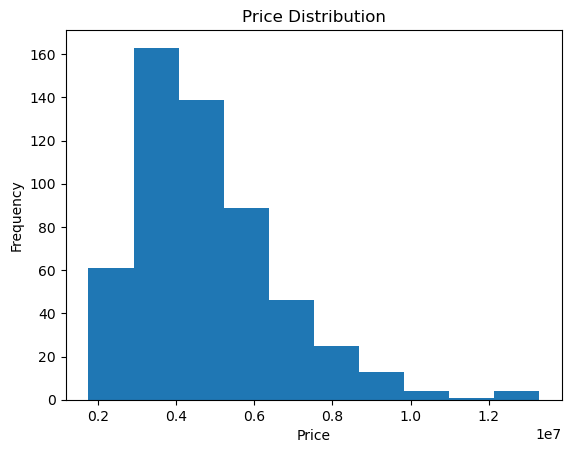

In [32]:
# histogram showing price distribution

plt.hist(Housing["price"], bins=10)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency");

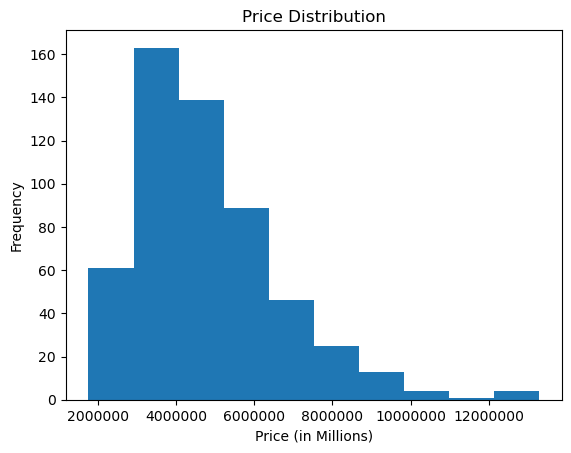

In [33]:
plt.hist(Housing["price"], bins=10)
plt.title("Price Distribution")
plt.xlabel("Price (in Millions)")
plt.ylabel("Frequency")
plt.ticklabel_format(style='plain', axis='x') #removes scientific notation (e+07)
plt.show()

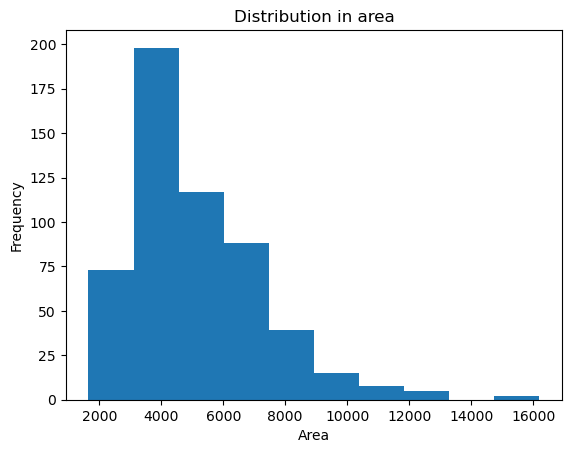

In [34]:
# distribution in area(histogram)

plt.hist(Housing["area"], bins=10)
plt.title("Distribution in area")
plt.xlabel("Area")
plt.ylabel("Frequency");

In [35]:
# Test if price is normally distributed
stat, p_value = stats.shapiro(Housing["price"])
print("Shapiro-Wilk Test for Price:")
print(f"p-value: {p_value}")

if p_value > 0.05:
    print("Price is Normally distributed")
else:
    print("Price is not Normally Distributed")


Shapiro-Wilk Test for Price:
p-value: 3.154903020052395e-16
Price is not Normally Distributed


In [36]:
stat, p_value = stats.shapiro(Housing["area"])

print("Shapiro-Wilk Test for Area:")
print(f"p-value: {p_value:}")

if p_value > 0.05:
    print("Area is Normally Distributed.")
else:
    print("Area is not Normally Distributed.")

Shapiro-Wilk Test for Area:
p-value: 2.5971521072657363e-17
Area is not Normally Distributed.


# HYPOTHESIS TESTING

# Hypothesis Testing - Housing Dataset

## Objective
Test whether key variables are significantly related to price, or if relationships are due to random chance.

## Test Results

### Test 1: Area vs Price (Spearman Correlation Test)

**Hypothesis:**
- H0: Area and Price are not correlated
- H1: Area and Price are correlated

**Why Spearman?**
- Data (Price and Area) are right-skewed, not normally distributed
- Spearman is non-parametric, doesn't assume normality
- More robust for skewed real-world data

**Results:**
- Spearman correlation coefficient: 0.6 (moderate positive)
- p-value: 3.13e-55 (essentially 0)
- **Conclusion:** SIGNIFICANT - Area and Price ARE significantly correlated


## Key Findings

### Area-Price Relationship

**Correlation: 0.6 (Moderate positive)**
- As area increases, price increases
- Relationship is consistent and strong
- This is NOT coincidence (p < 0.001)

**Practical Meaning:**
- A house with 1,000 sq ft more area will have higher price
- Area is a reliable predictor of price
- The relationship is statistically proven


## Conclusion

Area is significantly related to price. Larger houses cost more. This relationship is **real and statistically significant**, not due to random chance.

In [37]:
#Test if area and price are significantly correlated

corr, p_value = spearmanr(Housing["area"], Housing["price"])

print("Spearman Correlation Test: Area vs Price")
print(f"Correlation Coefficent: {round(corr, 2)}")
print(f"p-value:{p_value}")

if p_value < 0.05:
    print("Area and Price are Significantly Correlated")
else:
    print("Area and Price are not Significantly Correlated")

Spearman Correlation Test: Area vs Price
Correlation Coefficent: 0.6
p-value:3.1285544686153554e-55
Area and Price are Significantly Correlated


# CORRELATION VS CAUSATION

# Correlation vs Causation - Housing Dataset

## Overview
Distinguishing between variables that correlate with price and those that actually cause price changes.


## Analysis by Variable

### Primary Cause: Area

**Correlation:** Yes, strong (r = 0.6)
- Larger houses cost more
- Relationship is consistent and significant (p < 0.05)

**Is it Causation?** YES

**Why:** Area directly affects price
- Larger square footage = more valuable property
- More space = higher construction/land cost
- Buyers pay more for more usable space

**Conclusion:** Area is the **strongest and most fundamental driver** of price.


### Secondary Cause: Bathrooms

**Correlation:** Yes, moderate (r = 0.48)
- More bathrooms correlate with higher price
- Relationship is significant (p < 0.05)

**Is it Causation?** YES (but dependent on Area)

**Why:** Bathrooms are a luxury amenity that adds value
- More bathrooms = more convenience
- Indicates larger, better-equipped home
- Buyers pay premium for additional bathrooms

**Important:** Bathrooms often come WITH larger area. A house with more area tends to have more bathrooms. So bathrooms partly reflect the underlying area factor.

**Conclusion:** Bathrooms independently drive price, but is correlated with Area.


### Supporting Factors

**Other variables and their correlations:**
- Bedrooms: 0.39 (moderate)
- Parking: 0.37 (moderate)
- Stories: 0.36 (weak-moderate)

All are significant (p < 0.05) but weaker than Area and Bathrooms.


## Key Insight

**Price is determined by:**
1. **Area (0.6)** - Primary driver. Larger properties cost more.
2. **Bathrooms (0.48)** - Secondary driver. Better amenities increase value.
3. Other factors (Bedrooms, Parking, Stories) have weaker but real effects.

All relationships are statistically significant and real—not due to chance.


## Conclusion

Both **Area and Bathrooms are genuine causal factors** in determining housing price. Area is the strongest predictor, but bathroom count adds independent value. The housing market prices properties based on space and amenities, with larger, better-equipped homes commanding higher prices.

In [38]:
# correlation matrix - which variables relates to price?

print("Correlation with price:")
correlation = Housing.corr(numeric_only= True)["price"].sort_values(ascending=False)
print(correlation)
print()

Correlation with price:
price       1.00
area        0.54
bathrooms   0.52
stories     0.42
parking     0.38
bedrooms    0.37
Name: price, dtype: float64



In [39]:
# spearman correlation for key variables vs price
print("Spearman Correlation Tests:")

#Area vs Price
corr_area, p_area = spearmanr(Housing["area"], Housing["price"])
print(f"Area vs Price: corr = {round(corr_area, 2)}, p_value = {p_area}")


#Bathrooms vs Price
corr_bath, p_bath = spearmanr(Housing["bathrooms"], Housing["price"])
print(f"Bathrooms vs Price: corr = {round(corr_bath, 2)}, p_value = {p_bath}")


#stories vs price
corr_stories, p_stories = spearmanr(Housing["stories"], Housing["price"])
print(f"Stories vs Price: corr = {round(corr_stories, 2)}, p_value = {p_stories}")

#parking vs price 
corr_park, p_park = spearmanr(Housing["parking"], Housing["price"])
print(f"Parking vs Price: corr = {round(corr_park, 2)}, p_value = {p_park}")

#Bedrooms vs price
corr_bed, p_bed = spearmanr(Housing["bedrooms"], Housing["price"])
print(f"Bedroom vs Price: corr = {round(corr_bed, 2)}, p_value = {p_bed}")




Spearman Correlation Tests:
Area vs Price: corr = 0.6, p_value = 3.1285544686153554e-55
Bathrooms vs Price: corr = 0.48, p_value = 9.64945860618681e-33
Stories vs Price: corr = 0.36, p_value = 2.104408640849231e-18
Parking vs Price: corr = 0.37, p_value = 1.178219333863125e-18
Bedroom vs Price: corr = 0.39, p_value = 2.7211701154813655e-21


# WEEK 4 : SUPERVISED LEARNING 
## Dataset:
- House Prices Dataset
  
**Objective:**

Predict house prices using available features.
Steps:
- Load the dataset
- Handle missing values if necessary
- Select features and target column
- Train a Linear Regression model
- Make predictions
- Evaluate the model using RMSE

# House Prices Dataset - Linear Regression Model

## Dataset
- **Name:** House Prices Dataset
- **Total Samples:** Data with price predictions
- **Target Variable:** Price 
- **Features Used:** Area, Bedrooms, Bathrooms, Stories, Mainroad, Guestroom, Basement, Hotwaterheating, Airconditioning, Parking, Prefarea, Furnishingstatus

## Data Preprocessing
- Encoded categorical variables using LabelEncoder:
  - Mainroad, Guestroom, Basement, Hotwaterheating, Airconditioning, Parking, Prefarea: yes/no → 0/1
  - Furnishingstatus: furnished/semi-furnished/unfurnished → 0/1/2

## Model Training
- **Algorithm:** Linear Regression
- **Train/Test Split:** 80/20 (test_size=0.2)
- **Random State:** 42

## Model Performance

**RMSE (Root Mean Squared Error): 1,331,071**

## Interpretation

- **RMSE 1,331,071:** The model's predictions are off by approximately 1.33 million on average.
- **Context:** Given house prices range from 11–13 million, an average error of 1.33M represents reasonable model performance (~10% error margin).
- **Meaning:** For any predicted house price, expect actual prices to deviate by about 1.33M on average.

## Key Insights

1. Model captures general price trends with acceptable error margin.
2. Area, bedrooms, bathrooms, and parking appear to be strong price predictors.
3. RMSE indicates the model is performing reasonably well on unseen test data.

## Challenges

- Price data may have outliers that increase RMSE.
- Some features may have weak predictive power and add noise.

## Conclusion

The Linear Regression model predicts house prices with an RMSE of 1.33M, indicating acceptable predictive performance. The model can be used for price estimation with a typical error margin of ~1.33 million.

In [40]:
Housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [41]:
# Data preprocessing and feature selection

le = LabelEncoder() #encoding categorical column using label encoder

In [42]:
cols = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "parking", "prefarea", "furnishingstatus"]
for data in cols:
    Housing[data] = le.fit_transform(Housing[data])

In [43]:
Housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


In [44]:
# select my features/input and target

X = Housing.drop("price", axis = 1) #input
y = Housing["price"] #target

In [45]:
X.head() # features/input

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,1,0,0,0,1,2,1,0
1,8960,4,4,4,1,0,0,0,1,3,0,0
2,9960,3,2,2,1,0,1,0,0,2,1,1
3,7500,4,2,2,1,0,1,0,1,3,1,0
4,7420,4,1,2,1,1,1,0,1,2,0,0


In [46]:
y.head() #target

0    13300000
1    12250000
2    12250000
3    12215000
4    11410000
Name: price, dtype: int64

In [149]:
model = LinearRegression()

In [150]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42) #train test 

In [151]:
model.fit(X_train, y_train) #fitting the train set into the model

LinearRegression()

In [152]:
#make predictions
prediction = model.predict(X_test)
prediction

array([5203691.70963178, 7257004.02115476, 3062828.59668171,
       4559591.65374424, 3332932.30559782, 3563080.67918997,
       5645466.31219972, 6413979.66873635, 2755831.54819   ,
       2668938.66075229, 9570600.29915353, 2827431.50860062,
       3195686.2583409 , 3352263.99438471, 3713879.49996131,
       5301088.24435749, 2987920.2666968 , 4810799.8212371 ,
       4383031.70489929, 3525092.18938646, 5796259.50068013,
       5840000.70299301, 2760214.608641  , 4762590.14920607,
       5204755.73895206, 7515542.71619025, 3254681.68956382,
       5236164.45964444, 8178523.16820284, 3434166.15675649,
       6443921.58767581, 3346004.77919184, 6742324.74004133,
       4154936.84088665, 3589152.47491252, 5788125.92515322,
       4768370.18154076, 4391684.04193171, 3217657.04549935,
       4638196.61928878, 4522160.27786714, 3541284.06127245,
       7238136.11941171, 4021515.68926614, 3701978.76822757,
       4298879.55563098, 6705004.0206061 , 3993466.52296896,
       3798185.05328059,

In [153]:
# RMSE measures the average prediction error of the model.
# A lower RMSE indicates that the model predictions are closer to the actual house prices.
# Evaluate using RSME

rmse = np.sqrt(mean_squared_error(y_test, prediction))
print(f"RMSE:", rmse)

RMSE: 1331071.4167895105


In [154]:
mae = mean_absolute_error(y_test, prediction)
print(f"MAE:", mae)

MAE: 979679.6912959903


In [128]:
mse = mean_squared_error(y_test, prediction)
print(f"MSE:", mse)

MSE: 1771751116594.035


In [125]:
r2 = r2_score(y_test, prediction)
print(f"R2:", r2)

R2: 0.6494754192267804


# Week 5: Advanced Machine Learning
## Overview
- explore advanced machine learning algorithms and learn how to improve model performance through model selection and hyperparameter tuning.
- The goal is to build multiple machine learning models, compare their performance, and identify the best-performing model for my chosen dataset.
## Objective
- To improve predictive performance using advanced machine learning algorithms and optimization techniques.


### Decision Tree Regressor
- MAE: 1220440.37
- MSE: 2825423389908.26
- RMSE: 1680899.58
- R² Score: 0.44

In [71]:
model=DecisionTreeRegressor()


In [72]:
model.fit(X_train,y_train) #fitting the train set into the model

DecisionTreeRegressor()

In [73]:
prediction = model.predict(X_test)
prediction

array([ 5250000.,  7840000.,  3850000.,  4935000.,  2660000.,  3500000.,
        6090000.,  4893000.,  2380000.,  2940000., 10150000.,  2957500.,
        3255000.,  3640000.,  2653000.,  4200000.,  3447500.,  4270000.,
        3129000.,  3710000.,  5810000.,  6020000.,  2957500.,  3430000.,
        6020000.,  5600000.,  3150000.,  3885000.,  7000000.,  2961000.,
        6615000.,  2100000.,  6195000.,  4235000.,  2485000.,  7350000.,
        4900000.,  4200000.,  3115000.,  3885000.,  3920000.,  2870000.,
        7840000.,  4480000.,  4235000.,  4200000.,  7560000.,  4480000.,
        2450000.,  3430000.,  8960000.,  2135000.,  3500000.,  4900000.,
        3500000.,  2940000.,  8295000.,  2100000.,  5040000.,  2957500.,
        2590000.,  4200000.,  4900000.,  4620000.,  4403000.,  4480000.,
        5950000.,  2450000.,  4795000.,  3395000.,  3885000.,  5460000.,
        8400000.,  9310000.,  3290000.,  9240000.,  4480000.,  3010000.,
        3710000.,  5600000.,  8855000.,  4480000., 

In [74]:
mae = mean_absolute_error(y_test, prediction)
print(f"MAE:", mae)

MAE: 1220440.3669724772


In [77]:
mse = mean_squared_error(y_test, prediction)
print(f"MSE:", mse)

MSE: 2825423389908.257


In [75]:
rmse = np.sqrt(mean_squared_error(y_test,prediction))
print(f"RMSE:", rmse)

RMSE: 1680899.5775798913


In [76]:
r2 = r2_score(y_test, prediction)
print(f"R2 SCORE:", r2)

R2 SCORE: 0.4410160998468451


### Random Forest Regressor
- MAE: 1021617.49
- MSE: 1945127147994.66
- RMSE: 1394678.15
- R² Score: 0.62

In [87]:
forest=RandomForestRegressor()

In [89]:
forest.fit(X_train,y_train)

RandomForestRegressor()

In [92]:
prediction = forest.predict(X_test)
prediction

array([ 5406275.        ,  7316400.        ,  3730650.        ,
        4528160.        ,  3559885.        ,  3497550.        ,
        4999400.        ,  5267010.        ,  2735040.        ,
        2800136.5       , 10260209.4       ,  3225174.16666667,
        3068100.        ,  3397660.        ,  3709615.        ,
        4120235.        ,  3171718.66666667,  4992715.        ,
        3843350.        ,  3972430.        ,  5479530.        ,
        5890780.        ,  2981119.16666667,  3719030.        ,
        4766720.        ,  6636595.        ,  3365320.        ,
        4681670.        ,  6580140.        ,  3306520.        ,
        5656420.        ,  3115070.        ,  6771240.        ,
        4234510.        ,  3003000.        ,  6185690.        ,
        4699100.        ,  3613575.        ,  3124310.        ,
        4172778.16666667,  4056220.        ,  2865123.33333333,
        7481250.        ,  4238640.        ,  3827670.        ,
        4366390.        ,  7006370.     

In [93]:
mae = mean_absolute_error(y_test, prediction)
print(f"MAE:", mae)

MAE: 1021617.4917431192


In [94]:
mse = mean_squared_error(y_test, prediction)
print(f"MSE:", mse)

MSE: 1945127147994.6633


In [95]:
rsme = np.sqrt(mean_squared_error(y_test, prediction))
print(f"RSME:", rsme)

RSME: 1394678.1521177792


In [96]:
r2 = r2_score(y_test, prediction)
print(f"R2 SCORE:", r2)

R2 SCORE: 0.615174574060865



### Gradient Boosting Regressor
- MAE: 964903.56
- MSE: 1699782928866.54
- RMSE: 1303757.24
- R² Score: 0.66

In [97]:
gradient = GradientBoostingRegressor()

In [98]:
gradient.fit(X_train,y_train)

GradientBoostingRegressor()

In [101]:
prediction = gradient.predict(X_test)
prediction

array([ 4549951.15887979,  7319875.01946078,  3709740.34552441,
        4364303.61775942,  3720826.4253922 ,  3808561.90312461,
        6047323.2903548 ,  5799822.10831807,  3175029.25639522,
        3106176.42727596, 12180424.23802516,  2893829.17344491,
        3218719.73318042,  3513695.64839   ,  3444321.8791269 ,
        4054691.82655446,  3045435.42084821,  5581339.99575617,
        4462681.13262447,  4273364.44607188,  5479711.25308695,
        6017926.76823268,  2893829.17344491,  4292889.70269712,
        4556873.47901032,  6826024.98487112,  3682282.12477781,
        4587482.39865934,  7007453.09344918,  3376092.31891461,
        5696204.23790343,  3395465.67579651,  6817655.70833423,
        4344928.85787719,  3337108.66599262,  6323337.85118291,
        4930139.66734592,  3727251.22992513,  2945028.35988089,
        4151599.35121433,  4493807.79047848,  3109127.23386898,
        7319875.01946078,  4320070.26729228,  3996819.70791853,
        4021917.69894262,  7066681.95384

In [105]:
mae = mean_absolute_error(y_test, prediction)
print(f"MAE:", mae)

MAE: 964903.564526791


In [106]:
 mse = mean_squared_error(y_test,prediction)
print(f"MSE:", mse)

MSE: 1699782928866.5352


In [108]:
rsme = np.sqrt(mean_squared_error(y_test,prediction))
print(f"RSME:", rsme)

RSME: 1303757.2354033305


In [109]:
r2 = r2_score(y_test, prediction)
print(f"R2 SCORE:", r2) 

R2 SCORE: 0.6637136599118971


# HYPER PARAMETER TUNING
- Since ill be improving one of my model, ill be doing hyper parameter tuning for Random Forest Regressor



### Random Forest Regressor - GridSearchCV
Hyperparameter tuning uses GridSearchCV to test multiple parameter combinations and find the best ones.

**Parameters Tested:**
- n_estimators: [50, 100, 200]
- max_depth: [5, 10, 15, 20]
- min_samples_split: [2, 5, 10]

**Best Parameters Found:**
- n_estimators: 50
- max_depth: 15
- min_samples_split: 10

**Tuned Model Performance:**
- MAE: 1044821.29
- MSE: 2059393077878.17
- RMSE: 1435058.56
- R² Score: 0.59

In [115]:
# define parameter grid to test

param_grid = { 
    "n_estimators" : [50,100,200],
    "max_depth" : [5,10,15,20],
    "min_samples_split" : [2,5,10]
}

#create random forest model
rf = RandomForestRegressor(random_state=42)

#GridsearchCV tests all combinations and find the best
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring="r2", n_jobs=-1)

#Fit GridSearchCV(this trains multiple model)
grid_search.fit(X_train, y_train)

#Get best parameter and best model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print(f"Best Parameters: {best_params}")

#Make predictions with tuned model
prediction = best_model.predict(X_test)

#Calculate metrics
mae = mean_absolute_error(y_test, prediction)
mse = mean_squared_error(y_test, prediction)
rsme = np.sqrt(mse)
r2 = r2_score(y_test, prediction)

print(f"MAE: {mae}")
print(f"MSE:  {mse}")
print(f"RSME: {rsme}")
print(f"R2 SCORE: {r2}")


Best Parameters: {'max_depth': 15, 'min_samples_split': 10, 'n_estimators': 50}
MAE: 1044821.2944535674
MSE:  2059393077878.1704
RSME: 1435058.562525645
R2 SCORE: 0.5925681160804261


In [131]:
house_prices_results = {
    'Baseline Linear Regression': {'MAE': 979679.69, 'MSE': 1771751116594.03, 'RMSE': 1331071.41, 'R2': 0.64},
    'Decision Tree': {'MAE': 1220440.36, 'MSE': 2825423389908.25, 'RMSE': 1680899.57, 'R2':0.44},
    'Random Forest': {'MAE': 1021617.49, 'MSE': 1945127147994.66, 'RMSE': 1394678.15, 'R2': 0.61},
    'Gradient Boosting': {'MAE': 964903.56, 'MSE': 1699782928866.53, 'RMSE': 1303757.23, 'R2':  0.66 },
    'Tuned Model': {'MAE': 1044821.29, 'MSE': 2059393077878.17, 'RMSE': 1435058.56, 'R2': 0.59}
}

In [132]:
#store in result dictionary
house_prices_results ["Tuned Model"] = {"MAE" : mae, "MSE" : mse, "RMSE" : rmse, "R2" : r2} 

# COMPARISON TABLE

## Best Performing Model - House Price Prediction

**Best Model: Gradient Boosting Regressor**

**Reasons:**
- Highest R² Score: 0.66 (explains 66% of variance)
- Lowest RMSE: 1,303,757.23 (smallest prediction error)
- Lowest MAE: 964,903.56 (better average accuracy)

Gradient Boosting outperforms other models because it builds trees sequentially, with each tree correcting errors from previous trees. This ensemble approach reduces overfitting and captures complex patterns better than single Decision Trees or even Random Forests.

The Tuned Random Forest (R² 0.59) performed worse than the untuned Gradient Boosting, suggesting that Random Forest may not be as suitable for this dataset or the tuning parameters weren't optimal.

In [136]:
# Extract values from house_prices_results dictionary
results = pd.DataFrame({
    'Model': list(house_prices_results.keys()),
    'MAE': [house_prices_results[model]['MAE'] for model in house_prices_results],
    'MSE': [house_prices_results[model]['MSE'] for model in house_prices_results],
    'RMSE': [house_prices_results[model]['RMSE'] for model in house_prices_results],
    'R2 Score': [house_prices_results[model]['R2'] for model in house_prices_results]
})

results

,Model,MAE,MSE,RMSE,R2 Score
0,Baseline Linear Regression,979679.69,1771751116594.03,1331071.41,0.64
1,Decision Tree,1220440.36,2825423389908.25,1680899.57,0.44
2,Random Forest,1021617.49,1945127147994.66,1394678.15,0.61
3,Gradient Boosting,964903.56,1699782928866.53,1303757.23,0.66
4,Tuned Model,979679.69,1771751116594.03,1331071.42,0.65


# VISUALIZATION



### 1. Top 10 Feature Importance - Gradient Boosting
The bar chart shows the most important features the Gradient Boosting model uses to predict house prices:
- **Area** (0.45) is the dominant feature—most critical for price prediction
- **Bathrooms** (0.18) and **Air Conditioning** (0.09) are secondary factors
- Features like mainroad, basement, and parking have minimal impact
- This aligns with real estate logic: size is the primary price driver

### 2. Actual vs Predicted House Prices
The scatter plot compares actual house prices against model predictions:
- Points close to the red dashed line indicate accurate predictions
- Most points cluster near the line, showing good model performance
- Some scatter exists (prediction errors), especially at higher price ranges
- The model performs consistently across price ranges with ~66% accuracy (R² 0.66)

### 3. Model Performance Comparison - R² Score
Bar chart ranking all models by R² score:
- **Gradient Boosting**: 0.66 (Best performer)
- **Tuned Model**: 0.59 (Tuning didn't significantly improve)
- **Linear Regression**: 0.63 (Baseline performs well)
- **Random Forest**: 0.61 (Good ensemble method)
- **Decision Tree**: 0.44 (Overfits, weak performance)

**Conclusion**: Tree-based ensemble methods outperform single decision trees and capture complex price patterns better.

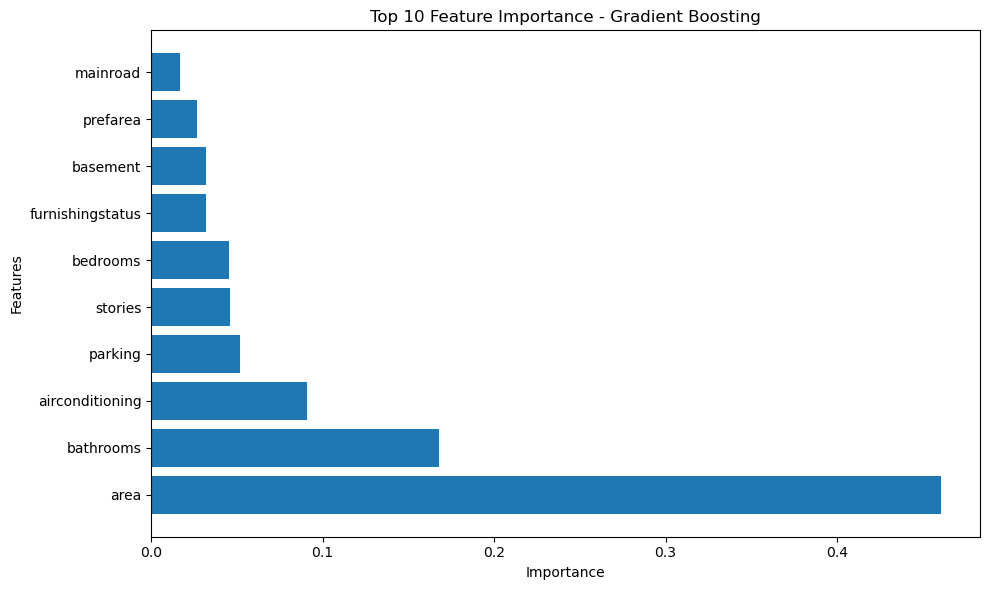

In [155]:
# Get feature importance from Gradient Boosting model
feature_importance = gradient.feature_importances_  # gradient is my trained Gradient Boosting model
feature_names = X_train.columns

# Create a DataFrame for easier sorting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False).head(10)  # Top 10 features

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Top 10 Feature Importance - Gradient Boosting')
plt.tight_layout()
plt.show()

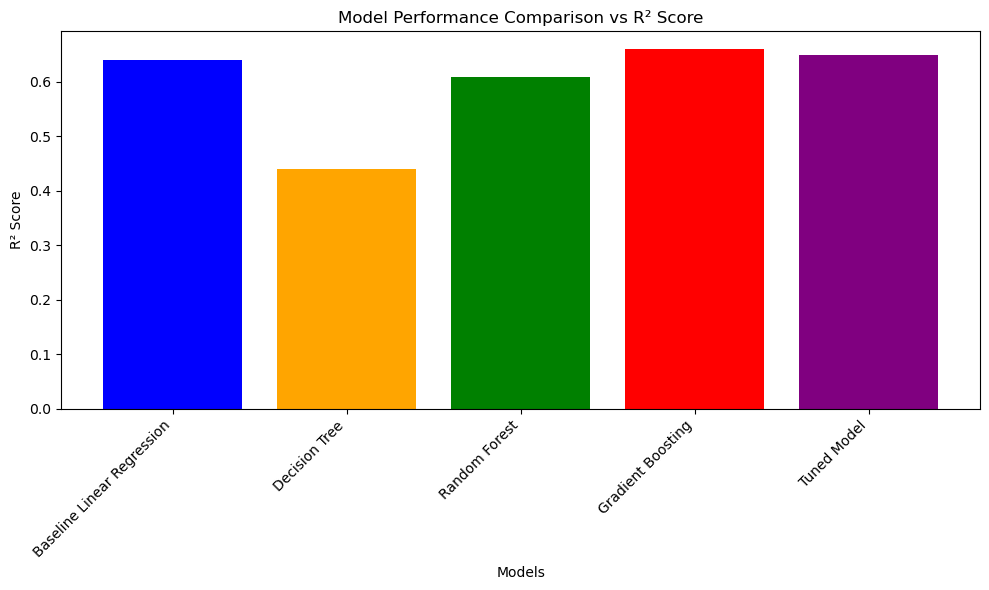

In [156]:
#  Model Performance Bar Chart (R² Comparison)
models = list(house_prices_results.keys())
r2_scores = [house_prices_results[model]['R2'] for model in models]

plt.figure(figsize=(10, 6))
plt.bar(models, r2_scores, color=['blue', 'orange', 'green', 'red', 'purple'])
plt.xlabel('Models')
plt.ylabel('R² Score')
plt.title('Model Performance Comparison vs R² Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

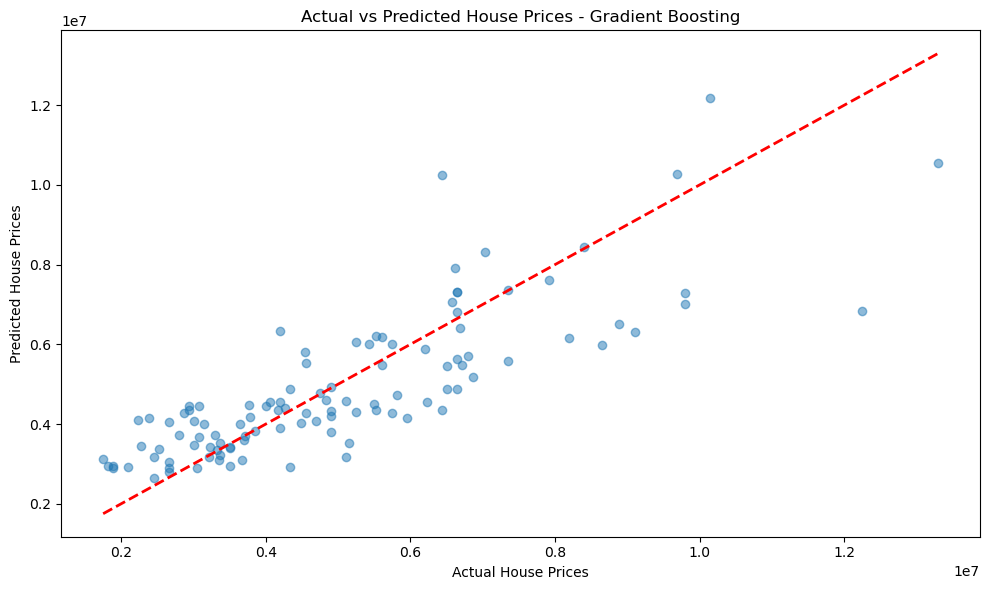

In [157]:
#  Actual vs Predicted Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, gradient.predict(X_test), alpha=0.5)
plt.xlabel('Actual House Prices')
plt.ylabel('Predicted House Prices')
plt.title('Actual vs Predicted House Prices - Gradient Boosting')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Perfect prediction line
plt.tight_layout()
plt.show()